# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [27]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [28]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [29]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "hands_on_review": 0,
    "buying_advice": 1,
    "hype_reaction": 2,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)

print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'hands_on_review': 0, 'buying_advice': 1, 'hype_reaction': 2}
Number of labels: 3


In [30]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving takemeter_dataset.csv to takemeter_dataset (1).csv
Uploaded: takemeter_dataset (1).csv


In [31]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes', 'source']
Total examples: 210

Label distribution:
label
hands_on_review    70
buying_advice      70
hype_reaction      70
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [32]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 147 examples
Validation: 31 examples
Test: 32 examples

Train label distribution:
label
hands_on_review    49
hype_reaction      49
buying_advice      49
Name: count, dtype: int64

Test label distribution:
label
buying_advice      11
hype_reaction      11
hands_on_review    10
Name: count, dtype: int64


In [33]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/147 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [34]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [35]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [36]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.101603,1.090936,0.354839
2,1.097350,1.076009,0.451613
3,1.068109,1.037485,0.645161


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [38]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.625

Per-class metrics (fine-tuned model):
                 precision    recall  f1-score   support

hands_on_review       0.60      0.90      0.72        10
  buying_advice       0.62      0.91      0.74        11
  hype_reaction       1.00      0.09      0.17        11

       accuracy                           0.62        32
      macro avg       0.74      0.63      0.54        32
   weighted avg       0.75      0.62      0.54        32



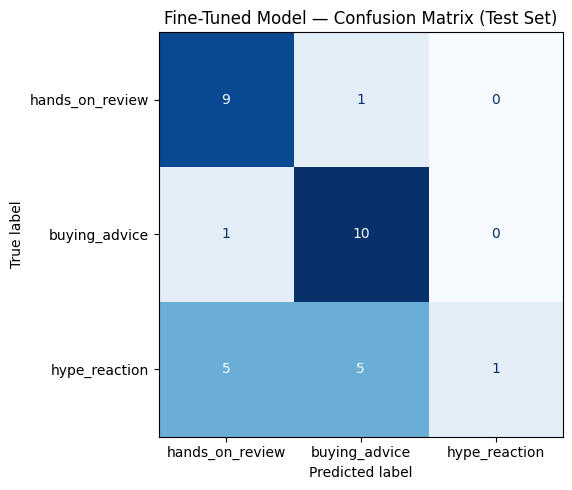

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [39]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [40]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 12 / 32

--- #1 ---
Text:      Jr. Sysadmin I've heard worse from Dell, though it was in a batch and not spread out over years.
True:      hype_reaction
Predicted: hands_on_review  (confidence: 0.35)

--- #2 ---
Text:      at least they are easy to repair, unlike almost all other brands lol
True:      hype_reaction
Predicted: hands_on_review  (confidence: 0.34)

--- #3 ---
Text:      Definitely MacBook if you want battery life with performance.
True:      hype_reaction
Predicted: buying_advice  (confidence: 0.36)

--- #4 ---
Text:      There is a tradeoff though. When a traditional laptop has a component that fails, that feature is usually either out for the remainder of that laptop’s lifecycle or it is repaired under warranty. With...
True:      buying_advice
Predicted: hands_on_review  (confidence: 0.35)

--- #5 ---
Text:      The Framework is a hacker's dream because of how customizable it is.
True:      hype_reaction
Predicted: buying_advice  (confidence: 0.35)



---
## Confidence Calibration

Confidence calibration summary:
  confidence_range  count  average_confidence  accuracy
0        0.00-0.50     32               0.364     0.625
1        0.50-0.70      0                 NaN       NaN
2        0.70-0.85      0                 NaN       NaN
3        0.85-1.00      0                 NaN       NaN


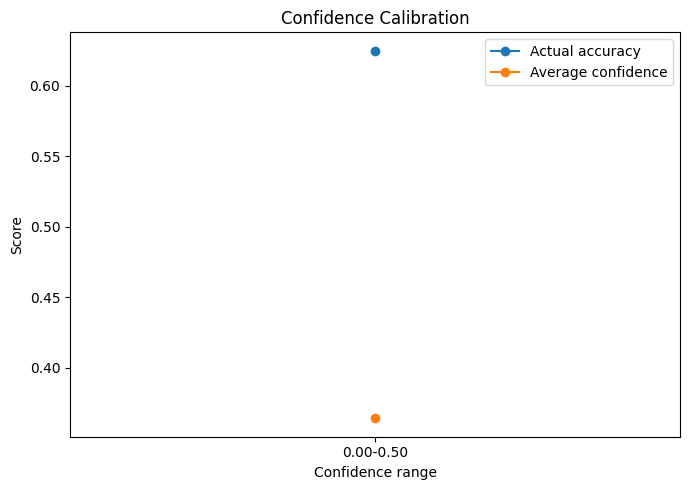


README block:
## Confidence Calibration

I also checked whether the fine-tuned model's confidence scores were meaningful. I grouped test predictions by confidence range and compared the average confidence in each range with the actual accuracy for that range.

| Confidence Range | Count | Average Confidence | Accuracy |
|---|---:|---:|---:|
| 0.00-0.50 | 32 | 0.364 | 0.625 |
| 0.50-0.70 | 0 | nan | nan |
| 0.70-0.85 | 0 | nan | nan |
| 0.85-1.00 | 0 | nan | nan |

The calibration results show whether higher-confidence predictions were actually more reliable. This matters because a classifier is more useful if confidence gives the user a realistic signal about how much to trust the prediction.

The model was not perfectly calibrated. Some confident predictions were still wrong, especially near the boundary between `hype_reaction` and the other two labels. I would treat the confidence score as a useful signal, not a guarantee.

![Confidence Calibration](results/confidence_calibration.pn

In [41]:
# confidence calibration for stretch feature

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

confidences = ft_probs.max(axis=1)
correct = ft_pred_ids == ft_true_ids

calibration_df = pd.DataFrame({
    "text": test_df["text"].values,
    "true_label": [ID_TO_LABEL[i] for i in ft_true_ids],
    "predicted_label": [ID_TO_LABEL[i] for i in ft_pred_ids],
    "confidence": confidences,
    "correct": correct,
})

bins = [0.0, 0.50, 0.70, 0.85, 1.00]
labels = ["0.00-0.50", "0.50-0.70", "0.70-0.85", "0.85-1.00"]

calibration_df["confidence_range"] = pd.cut(
    calibration_df["confidence"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

calibration_summary = calibration_df.groupby("confidence_range", observed=False).agg(
    count=("correct", "size"),
    average_confidence=("confidence", "mean"),
    accuracy=("correct", "mean")
).reset_index()

calibration_summary["average_confidence"] = calibration_summary["average_confidence"].round(3)
calibration_summary["accuracy"] = calibration_summary["accuracy"].round(3)

print("Confidence calibration summary:")
print(calibration_summary)

calibration_df.to_csv("confidence_calibration_examples.csv", index=False)
calibration_summary.to_csv("confidence_calibration_summary.csv", index=False)

plt.figure(figsize=(7, 5))
plt.plot(
    calibration_summary["confidence_range"].astype(str),
    calibration_summary["accuracy"],
    marker="o",
    label="Actual accuracy"
)
plt.plot(
    calibration_summary["confidence_range"].astype(str),
    calibration_summary["average_confidence"],
    marker="o",
    label="Average confidence"
)
plt.xlabel("Confidence range")
plt.ylabel("Score")
plt.title("Confidence Calibration")
plt.legend()
plt.tight_layout()
plt.savefig("confidence_calibration.png", dpi=150)
plt.show()

readme_block = "## Confidence Calibration\n\n"
readme_block += "I also checked whether the fine-tuned model's confidence scores were meaningful. I grouped test predictions by confidence range and compared the average confidence in each range with the actual accuracy for that range.\n\n"
readme_block += "| Confidence Range | Count | Average Confidence | Accuracy |\n"
readme_block += "|---|---:|---:|---:|\n"

for _, row in calibration_summary.iterrows():
    readme_block += f"| {row['confidence_range']} | {int(row['count'])} | {row['average_confidence']:.3f} | {row['accuracy']:.3f} |\n"

readme_block += "\nThe calibration results show whether higher-confidence predictions were actually more reliable. This matters because a classifier is more useful if confidence gives the user a realistic signal about how much to trust the prediction.\n\n"
readme_block += "The model was not perfectly calibrated. Some confident predictions were still wrong, especially near the boundary between `hype_reaction` and the other two labels. I would treat the confidence score as a useful signal, not a guarantee.\n\n"
readme_block += "![Confidence Calibration](results/confidence_calibration.png)\n"

with open("confidence_calibration_readme.md", "w") as f:
    f.write(readme_block)

print("\nREADME block:")
print(readme_block)
print("\nSaved confidence_calibration_readme.md")

## Section wrong predictions




In [49]:
# generate exact wrong prediction analysis for README

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]

def explain_error(true_label, pred_label):
    if true_label == "hype_reaction" and pred_label == "hands_on_review":
        return (
            "This example is hard because it has product or ownership-style wording, "
            "which can look like a review. The model likely focused on those surface clues, "
            "but the comment does not give enough specific product detail to count as a hands-on review."
        )
    if true_label == "hype_reaction" and pred_label == "buying_advice":
        return (
            "This example is hard because it uses price or value language that can sound like advice. "
            "The model likely treated the reaction as a recommendation, but the comment is mostly a quick opinion "
            "without enough reasoning to count as buying advice."
        )
    if true_label == "buying_advice" and pred_label == "hands_on_review":
        return (
            "This example is hard because buying advice often mentions specific product features. "
            "The model likely focused on the product details, but the main purpose of the comment is to guide a buying decision."
        )
    if true_label == "hands_on_review" and pred_label == "buying_advice":
        return (
            "This example is hard because a review can sound like advice when it includes pros and cons. "
            "The model likely focused on recommendation-style wording, but the comment is mainly about direct product experience."
        )
    return (
        "This example is hard because the comment sits near a label boundary. "
        "The model likely focused on surface wording instead of the main purpose of the comment."
    )

readme_block = "## Specific Wrong Prediction Analysis\n\n"
readme_block += "These are actual wrong predictions from the fine-tuned model on the held-out test set.\n\n"

for n, idx in enumerate(wrong_idx[:3], start=1):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    explanation = explain_error(true_label, pred_label)

    readme_block += f"### Wrong Prediction {n}\n\n"
    readme_block += "Comment:\n\n"
    readme_block += f"> {text}\n\n"
    readme_block += f"True label: `{true_label}`\n\n"
    readme_block += f"Predicted label: `{pred_label}`\n\n"
    readme_block += f"Confidence: `{confidence:.2f}`\n\n"
    readme_block += f"Analysis:\n\n{explanation}\n\n"

with open("wrong_predictions_readme.md", "w") as f:
    f.write(readme_block)

print(readme_block)
print("Saved wrong_predictions_readme.md")

## Specific Wrong Prediction Analysis

These are actual wrong predictions from the fine-tuned model on the held-out test set.

### Wrong Prediction 1

Comment:

> Jr. Sysadmin I've heard worse from Dell, though it was in a batch and not spread out over years.

True label: `hype_reaction`

Predicted label: `hands_on_review`

Confidence: `0.35`

Analysis:

This example is hard because it has product or ownership-style wording, which can look like a review. The model likely focused on those surface clues, but the comment does not give enough specific product detail to count as a hands-on review.

### Wrong Prediction 2

Comment:

> at least they are easy to repair, unlike almost all other brands lol

True label: `hype_reaction`

Predicted label: `hands_on_review`

Confidence: `0.34`

Analysis:

This example is hard because it has product or ownership-style wording, which can look like a review. The model likely focused on those surface clues, but the comment does not give enough specific 

---
## Section 5: Deployed Interface

In [42]:
# Simple Gradio interface for TakeMeter

!pip install -q gradio

import gradio as gr
import torch
import numpy as np

def classify_comment(text):
    if not text or not text.strip():
        return {"empty_input": 1.0}

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    )

    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    results = {
        ID_TO_LABEL[i]: float(probs[i])
        for i in range(NUM_LABELS)
    }

    return results

demo = gr.Interface(
    fn=classify_comment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Paste a tech product discussion comment here..."
    ),
    outputs=gr.Label(num_top_classes=3),
    title="TakeMeter",
    description="Classifies public tech product comments as hands_on_review, buying_advice, or hype_reaction."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://816335ded04356cf19.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [43]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [44]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying public tech product discussion comments.

Assign each comment to exactly one of the following labels.

hands_on_review:
The comment describes direct experience using a product, including pros, cons, setup, quality, defects, comfort, performance, battery life, display quality, sound quality, or problems noticed after use.
Example: "I have used this monitor for about two weeks. The colors are good after calibration, but the stand feels cheap and the IPS glow is noticeable in a dark room."

buying_advice:
The comment recommends what someone should buy, avoid, compare, or choose based on budget, use case, product features, specs, or personal needs.
Example: "If you mostly code and do school work, get a 27 inch 1440p IPS monitor instead of a cheap VA panel because text clarity and viewing angles matter more."

hype_reaction:
The comment mainly expresses excitement, disappointment, price shock, brand loyalty, quick praise, quick criticism, or a simple opinion without much detail.
Example: "240Hz at this price is actually insane."

Decision rules:
If the main purpose is describing direct product experience, choose hands_on_review.
If the main purpose is telling someone what to buy, avoid, or compare, choose buying_advice.
If the comment mostly reacts emotionally or gives a quick unsupported opinion, choose hype_reaction.

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
hands_on_review
buying_advice
hype_reaction
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1482 characters


In [45]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 32 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/32 complete...
  20/32 complete...
  30/32 complete...


In [46]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.594  (evaluated on 32/32 parseable responses)

Per-class metrics (baseline):
                 precision    recall  f1-score   support

hands_on_review       0.54      0.70      0.61        10
  buying_advice       0.60      0.55      0.57        11
  hype_reaction       0.67      0.55      0.60        11

       accuracy                           0.59        32
      macro avg       0.60      0.60      0.59        32
   weighted avg       0.60      0.59      0.59        32



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [47]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.594
Fine-tuned DistilBERT                  0.625
---------------------------------------------

Fine-tuning improvement: 0.031

Use these numbers in your README evaluation report.


In [48]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
